#### Dataset Selection

**Dataset Name:** Diabetes Health Indicators

**Source:** https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset?select=diabetes_binary_5050split_health_indicators_BRFSS2015.csv

**Problem Type:** Binary Classification

**Description:** The goal is to predict whether a survey respondent has prediabetes/diabetes (Class 1) or no diabetes (Class 0). The dataset contains 70,692 observations and 21 features.

## Part 1

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim


In [4]:
class NeuralNetwork:
    def __init__(self, d, m, p, learning_rate=0.01):
        np.random.seed(42)
        self.d = d # number of features
        self.m = m # number of hidden neurons in 1 layer
        self.p = p # number of output neurones in 1 output layer
        self.lr = learning_rate
        
        # W_h: Weights between Input and Hidden Layer, d * m matrix
        self.W_h = np.random.randn(self.d, self.m) * 0.01
        # W_o: Weights between Hidden and Output Layer, m * p matrix
        self.W_o = np.random.randn(self.m, self.p) * 0.01

        # b_h: Bias for Hidden Layer, m-dimensional vector
        self.b_h = np.zeros((1, self.m))
        # b_o: Bias for Output Layer, p-dimensional vector
        self.b_o = np.zeros((1, self.p))
        
        # stored values needed in backprop
        self.z_h = None
        self.a_h = None
        self.z_o = None
        self.a_o = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def sigmoid_derivative(self, f_z):
        return f_z * (1 - f_z)

    def forward(self, X):
        # Hidden Layer calculation ==> (n,d) @ (d,m) = (n,m) + (1,m)
        self.z_h = X @ self.W_h + self.b_h
        self.a_h = self.sigmoid(self.z_h) 
        
        # Output Layer calculation ==> (n,m) @ (m,p) = (n, p) + (1,p)
        self.z_o = self.a_h @ self.W_o + self.b_o
        self.a_o = self.sigmoid(self.z_o)
        
        return self.a_o

    def cost(self, y_true, y_pred):
        # MSE
        return np.mean((y_true - y_pred) ** 2)

    def backward(self, X, y_true, y_pred):
        n = X.shape[0]
        # error = (n,p) - (n,p) * (n,p) = (n,p), element wise product
        output_error = (y_pred - y_true) * self.sigmoid_derivative(y_pred)
        
        # Calculate gradients for W_o and b_o
        grad_W_o = (self.a_h.T @ output_error) / n # (m,n) @ (n,p) = (m,p)
        grad_b_o = np.sum(output_error, axis=0, keepdims=True) / n # sum((n,p), axis=0) = (1,p)

        # Hidden Layer Gradients, ((n,p) @ (p,m)) * (n,m) = (n,m)
        hidden_error = (output_error @ self.W_o.T) * self.sigmoid_derivative(self.a_h)
        
        # Calculate gradients for W_h and b_h
        grad_W_h = (X.T @ hidden_error) / n # (d,n) @ (n,m) = (d,m)
        grad_b_h = np.sum(hidden_error, axis=0, keepdims=True) / n # sum((n,m), axis=0) = (1,m)

        # Update Weights (Gradient Descent)
        self.W_o -= self.lr * grad_W_o
        self.b_o -= self.lr * grad_b_o
        self.W_h -= self.lr * grad_W_h
        self.b_h -= self.lr * grad_b_h

    def train(self, X_train, y_train, itrs, batch_size=32):
        
        for _ in range(itrs):
            # Shuffle data
            permutation = np.random.permutation(X_train.shape[0])
            X_shuffled = X_train[permutation]
            y_shuffled = y_train[permutation]
            
            # Mini-batch Gradient Descent
            for i in range(0, X_train.shape[0], batch_size):
                # Get batch
                X_batch = X_shuffled[i:i+batch_size]
                y_batch = y_shuffled[i:i+batch_size]
                # Forward
                y_pred = self.forward(X_batch)        
                # Backward & Update
                self.backward(X_batch, y_batch, y_pred)
        
    def predict(self, X):
        predictions = self.forward(X)
        return (predictions > 0.5).astype(int)

#### Exploratory data analysis

In [5]:
filename = "diabetes_binary_5050split_health_indicators_BRFSS2015.csv"
df = pd.read_csv(filename)

In [6]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [7]:
df.isna().sum()

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15  MentHlth           

In [9]:
df.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,...,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000
mean,0.500000,0.563458,0.525703,0.975259,29.856985,0.475273,0.062171,0.147810,0.703036,0.611795,...,0.954960,0.093914,2.837082,3.752037,5.810417,0.252730,0.456997,8.584055,4.920953,5.698311
std,0.500004,0.495960,0.499342,0.155336,7.113954,0.499392,0.241468,0.354914,0.456924,0.487345,...,0.207394,0.291712,1.113565,8.155627,10.062261,0.434581,0.498151,2.852153,1.029081,2.175196
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,7.000000,4.000000,4.000000
50%,0.500000,1.000000,1.000000,1.000000,29.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,9.000000,5.000000,6.000000
75%,1.000000,1.000000,1.000000,1.000000,33.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,4.000000,2.000000,6.000000,1.000000,1.000000,11.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [10]:
dp_count = df.duplicated().sum()
print(f"Number of duplicate rows: {dp_count}")

Number of duplicate rows: 1635


In [11]:
df.drop_duplicates(inplace=True)

array([[<Axes: title={'center': 'Diabetes_binary'}>,
        <Axes: title={'center': 'HighBP'}>,
        <Axes: title={'center': 'HighChol'}>,
        <Axes: title={'center': 'CholCheck'}>],
       [<Axes: title={'center': 'BMI'}>,
        <Axes: title={'center': 'Smoker'}>,
        <Axes: title={'center': 'Stroke'}>,
        <Axes: title={'center': 'HeartDiseaseorAttack'}>],
       [<Axes: title={'center': 'PhysActivity'}>,
        <Axes: title={'center': 'Fruits'}>,
        <Axes: title={'center': 'Veggies'}>,
        <Axes: title={'center': 'HvyAlcoholConsump'}>],
       [<Axes: title={'center': 'AnyHealthcare'}>,
        <Axes: title={'center': 'NoDocbcCost'}>,
        <Axes: title={'center': 'GenHlth'}>,
        <Axes: title={'center': 'MentHlth'}>],
       [<Axes: title={'center': 'PhysHlth'}>,
        <Axes: title={'center': 'DiffWalk'}>,
        <Axes: title={'center': 'Sex'}>, <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Education'}>,
        <Axes: title

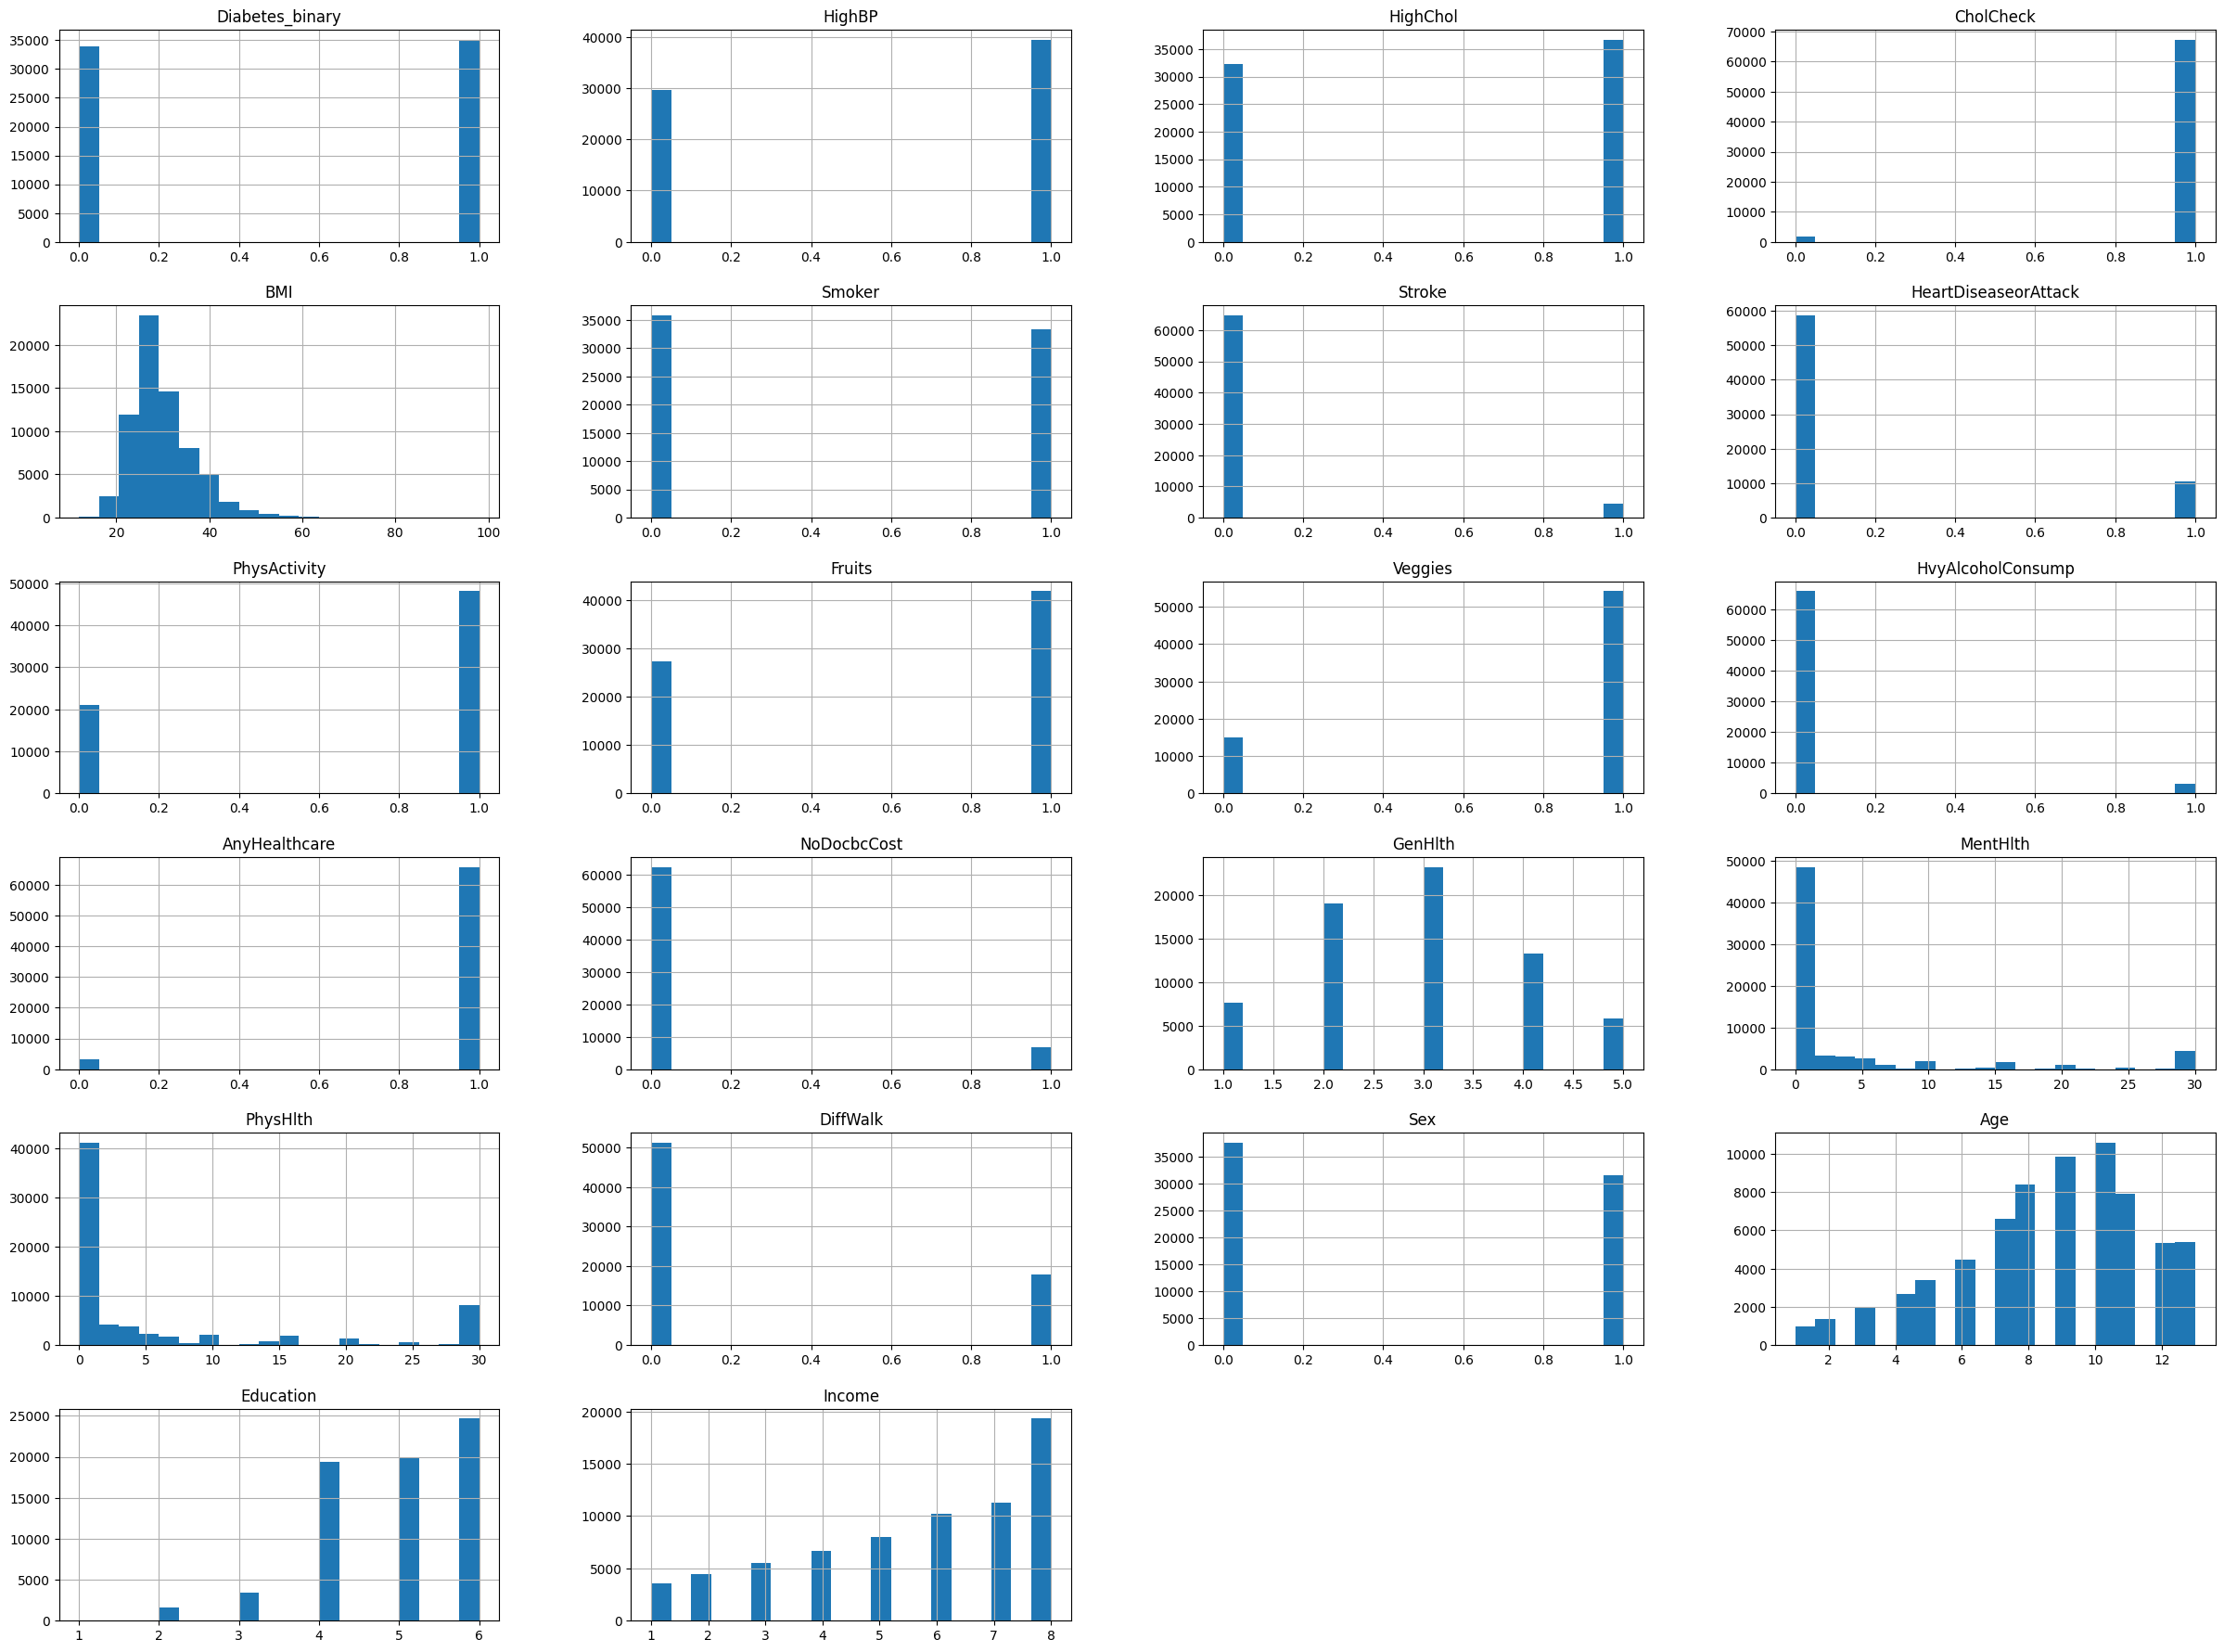

In [12]:
df.hist(bins=20,figsize=(30,30),layout=(8,4))

In [13]:
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

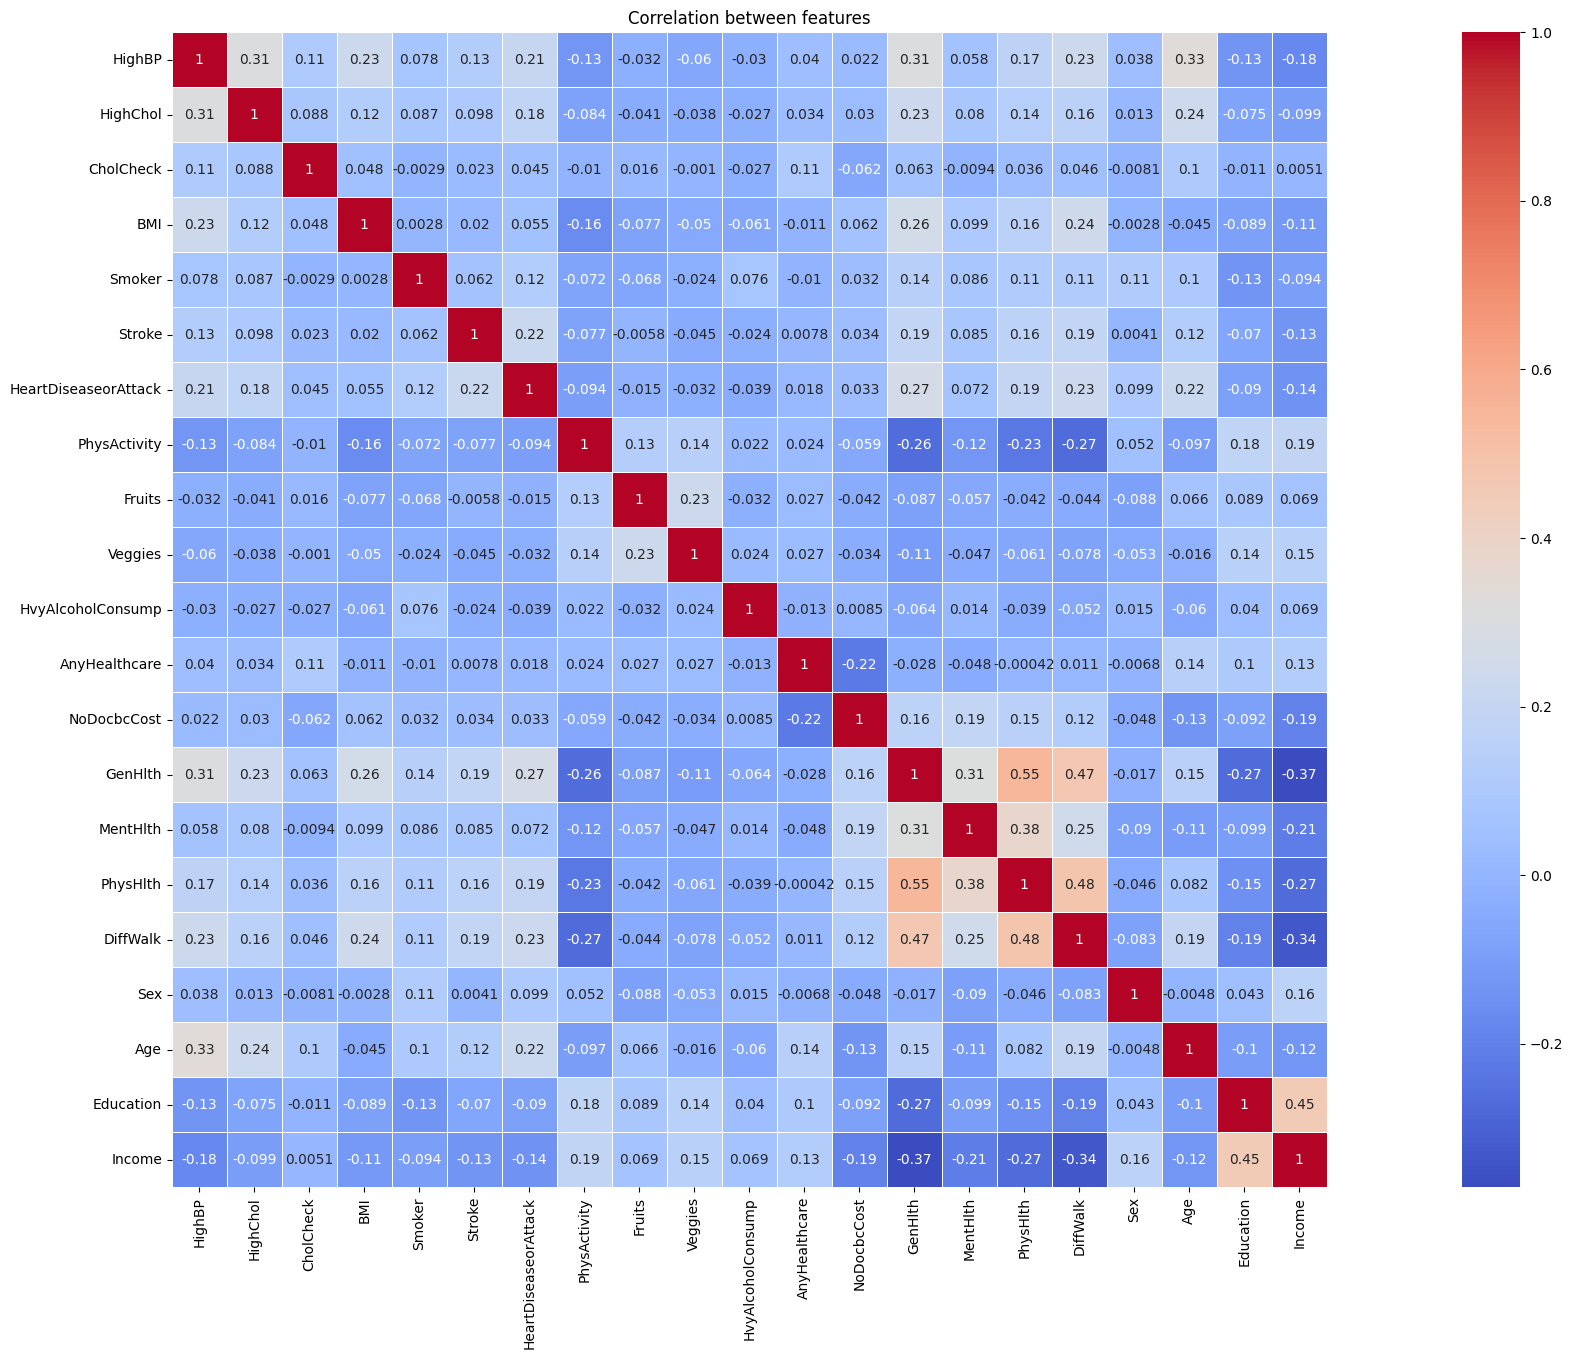

In [14]:
plt.figure(figsize=(35,15))
sns.heatmap(X.corr(),vmax=1, square=True, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation between features')
plt.show()

#### Neural Network

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    df[X.columns], 
    y,
    test_size=0.2,
    random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
y_train = y_train.values.reshape(-1, 1)
y_test = y_test.values.reshape(-1, 1)

In [16]:
# d = 21 (features), m = 10 (hidden neurons), p = 1 (output neuron)
neural_network = NeuralNetwork(d=21, m=10, p=1, learning_rate=0.1)

In [17]:
# Train Model
print("Training (Mini-batch Gradient Descent)")
# Using 1000 epochs and batch_size of 64
neural_network.train(X_train, y_train, itrs=1000, batch_size=64)

Training (Mini-batch Gradient Descent)


In [18]:
pred = neural_network.predict(X_test)
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)

print(f"Precision = {precision:.4f}")
print(f"Recall    = {recall:.4f}")
print(f"F1 Score  = {f1:.4f}")

Precision = 0.7444
Recall    = 0.8082
F1 Score  = 0.7750


#### Performance & Optimization 
To handle the large dataset size efficiently, I used a vectorized Mini-Batch Gradient Descent with a batch size of 64, which reduced runtime compared to stochastic gradient descent. Plus, the efficiency gains allowed me to train on the entire dataset rather than a subset.

## Part 2

#### Task 1

Ressources used:

1-

https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html

I used this to understand how to implement the forward phase. It explains how to create a class that inherits from nn.Module and how to stack layers like nn.Linear and nn.ReLU to define the architecture.

2-

https://www.geeksforgeeks.org/deep-learning/how-to-implement-neural-networks-in-pytorch/

I used this to understand how to implement the backward phase and the training loop. It has a practical example of how to track computations using PyTorch's Autograd system (via loss.backward()) and how to use an optimizer (like optim.SGD) to update the weights automatically.

#### Task 2

##### Note: Exploratory Data Analysis has been done above in part 1

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [20]:
class NN(nn.Module):
    def __init__(self, d, m, o):
        super(NN, self).__init__()
        self.layer1 = nn.Linear(d, m)
        self.activation1 = nn.ReLU()        
        self.layer2 = nn.Linear(m, o)
        self.activation2 = nn.Sigmoid() # Sigmoid required for binary classification output
        
    def forward(self, x):
        x = self.layer1(x)
        x = self.activation1(x)
        x = self.layer2(x)
        x = self.activation2(x)
        return x

In [22]:
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).view(-1, 1) # Reshape to (n, 1)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).view(-1, 1)


In [ ]:
d = X_train_tensor.shape[1]
m = 16 # hyperparameter for hidden neurons size
model = NN(d=d, m=m, o=1)
model.to(device)